In [1]:
from datetime import datetime
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns

In [2]:
microsoft = pd.read_csv(r"C:\Users\KIIT\Downloads\MicrosoftStock.csv", usecols=lambda col: col != 'index')
print(microsoft.head())

         date   open   high    low  close    volume  Name
0  2013-02-08  27.35  27.71  27.31  27.55  33318306  MSFT
1  2013-02-11  27.65  27.92  27.50  27.86  32247549  MSFT
2  2013-02-12  27.88  28.00  27.75  27.88  35990829  MSFT
3  2013-02-13  27.93  28.11  27.88  28.03  41715530  MSFT
4  2013-02-14  27.92  28.06  27.87  28.04  32663174  MSFT


In [3]:
microsoft.shape

(1259, 7)

In [4]:
microsoft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1259 non-null   object 
 1   open    1259 non-null   float64
 2   high    1259 non-null   float64
 3   low     1259 non-null   float64
 4   close   1259 non-null   float64
 5   volume  1259 non-null   int64  
 6   Name    1259 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 69.0+ KB


In [5]:
microsoft.describe()

,open,high,low,close,volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,51.026394,51.436007,50.630397,51.063081,3.386946e+07
std,14.859387,14.930144,14.774630,14.852117,1.958979e+07
min,27.350000,27.600000,27.230000,27.370000,7.425603e+06
25%,40.305000,40.637500,39.870000,40.310000,2.254879e+07
50%,47.440000,47.810000,47.005000,47.520000,2.938758e+07
75%,59.955000,60.435000,59.275000,59.730000,3.842024e+07
max,95.140000,96.070000,93.720000,95.010000,2.483542e+08


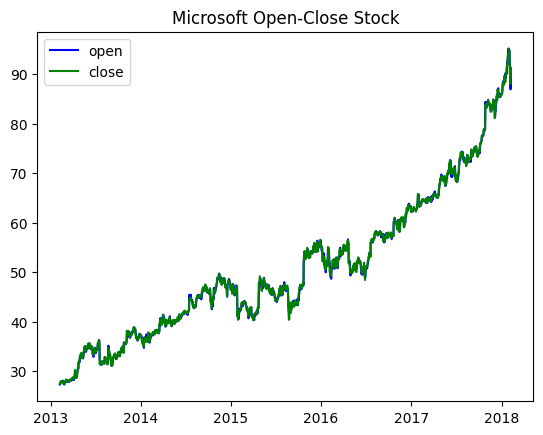

In [6]:
#Exploratory Data Analysis
#EDA is an approach to analyzing the data using visual techniques. 
#It is used to discover trends, and patterns, or to check assumptions 
#with the help of statistical summaries and graphical representations.
microsoft['date'] = pd.to_datetime(microsoft['date'])
plt.plot(microsoft['date'], 
		microsoft['open'], 
		color="blue", 
		label="open") 
plt.plot(microsoft['date'], 
		microsoft['close'], 
		color="green", 
		label="close") 
plt.title("Microsoft Open-Close Stock") 
plt.legend() 

# This code is modified by Susobhan Akhuli

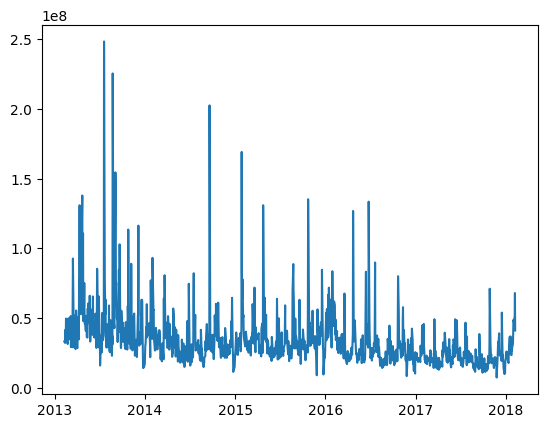

In [7]:
plt.plot(microsoft['date'],
         microsoft['volume'])
plt.show()

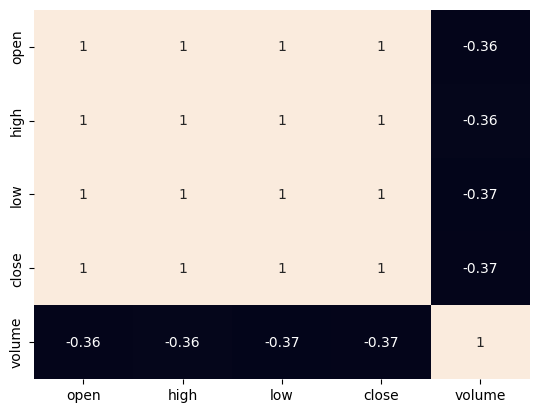

In [8]:
sns.heatmap(microsoft.select_dtypes(include=np.number).corr(), 
			annot=True, 
			cbar=False) 
plt.show() 
# This code is modified by Susobhan Akhuli

Text(0.5, 1.0, 'Microsoft Stock Prices')

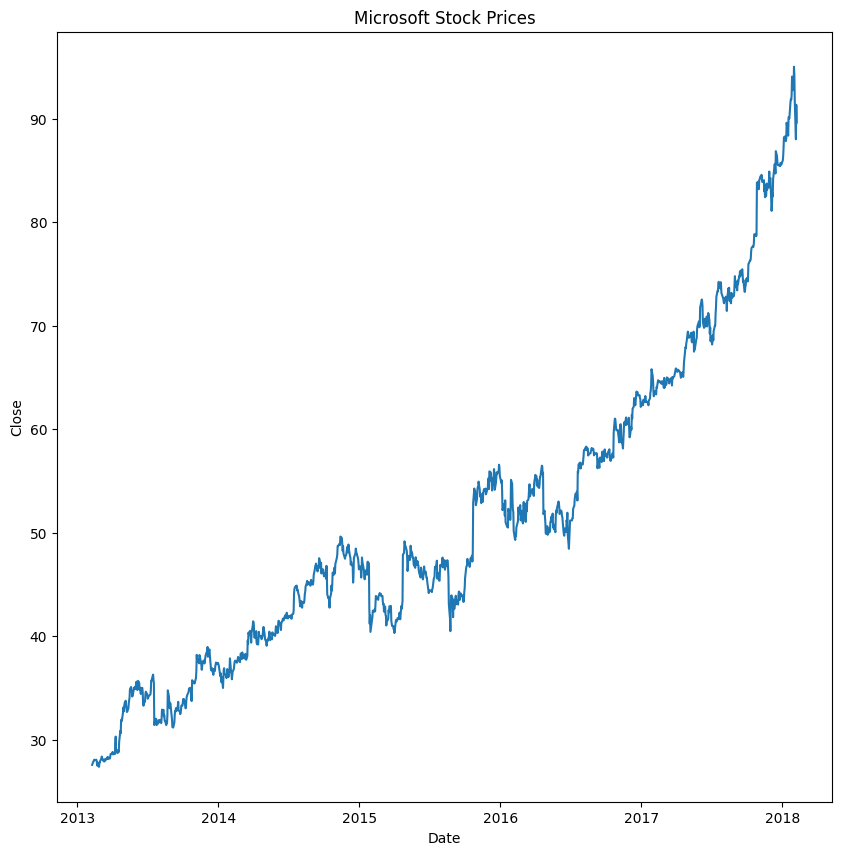

In [9]:
microsoft['date'] = pd.to_datetime(microsoft['date'])
prediction = microsoft.loc[(microsoft['date']
                            > datetime(2013, 1, 1))
                            & (microsoft['date']
                            < datetime(2018, 1, 1))]

plt.figure(figsize=(10, 10))
plt.plot(microsoft['date'], microsoft['close'])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Microsoft Stock Prices")

In [10]:
# prepare the training set samples 
msft_close = microsoft.filter(['close']) 
dataset = msft_close.values 
training = int(np.ceil(len(dataset) * .95)) 

# scale the data 
ss = StandardScaler() 
ss = ss.fit_transform(dataset) 

train_data = ss[0:int(training), :] 

x_train = [] 
y_train = [] 

# considering 60 as the batch size, 
# create the X_train and y_train 
for i in range(60, len(train_data)): 
	x_train.append(train_data[i-60:i, 0]) 
	y_train.append(train_data[i, 0]) 

x_train, y_train = np.array(x_train), np.array(y_train) 
X_train = np.reshape(x_train, 
					(x_train.shape[0], 
					x_train.shape[1], 1)) 

# This code is modified by Susobhan Akhuli

In [12]:
#Build the Model
#To tackle the Time Series or Stock Price Prediction problem statement, 
#we build a Recurrent Neural Network model, that comes in very handy to 
#memorize the previous state using cell state and memory state. Since RNNs are hard to 
#train and prune to Vanishing Gradient, we use LSTM which is the RNN gated cell,
#LSTM reduces the problem of Vanishing gradients. 
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
model = Sequential()
# Explicit Input layer
model.add(Input(shape=(X_train.shape[1], 1)))
# First LSTM layer
model.add(LSTM(units=64, return_sequences=True))
# Second LSTM layer
model.add(LSTM(units=64))
# Fully connected layer
model.add(Dense(128, activation='relu'))
# Dropout for regularization
model.add(Dropout(0.5))
# Output layer
model.add(Dense(1))
# Model summary
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
from keras.metrics import RootMeanSquaredError 
model.compile(optimizer='adam', 
            loss='mae', 
            metrics=[RootMeanSquaredError()]) 
history = model.fit(X_train, y_train, 
					epochs=20) 
# This code is modified by Susobhan Akhuli

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.2500 - root_mean_squared_error: 0.3708
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1408 - root_mean_squared_error: 0.1909
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1252 - root_mean_squared_error: 0.1724
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1173 - root_mean_squared_error: 0.1636
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1206 - root_mean_squared_error: 0.1663
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1083 - root_mean_squared_error: 0.1499
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1067 - root_mean_squared_error: 0.1439
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1095 - root_mean_squared_error: 0.1472
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1016 - root_mean_squared_error: 0.1390
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1037 - root_mean_squared_error: 0.1450

In [14]:
#Model Evaluation
#Now as we have our model ready let’s evaluate its performance on the
#validation data using different metrics. For this purpose, we will 
#first predict the class for the validation data using this model 
#and then compare the output with the true labels.
testing = ss[training - 60:, :]
x_test = []
y_test = dataset[training:, :]
for i in range(60, len(testing)):
    x_test.append(testing[i-60:i, 0])

x_test = np.array(x_test)
X_test = np.reshape(x_test,
                    (x_test.shape[0],
                     x_test.shape[1], 1))
pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 346ms/step


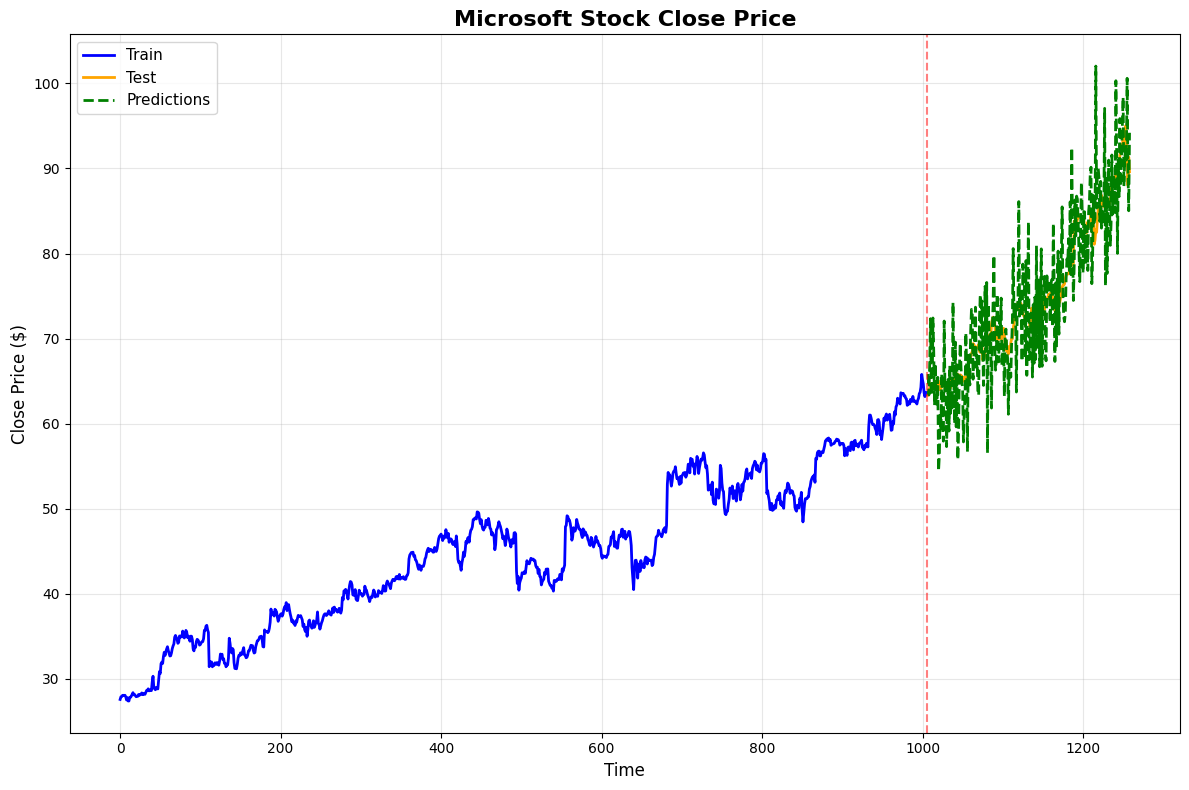

Training data size: 1007 points
Testing data size: 252 points
Prediction range: $54.41 - $102.04


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# Add any other imports you're using for your model (e.g., from sklearn.linear_model import LinearRegression)
# Assuming you have your data loaded (replace this with your actual data loading)
# microsoft = pd.read_csv('microsoft_stock.csv')
# Define the training split point (e.g., 80% for training)
training_size = int(len(microsoft) * 0.8)  # 80% training, 20% testing
# Or use a specific number: training_size = 800
# Split the data
train = microsoft.iloc[:training_size].copy()  # Training data
test = microsoft.iloc[training_size:].copy()   # Testing data
# ============================================
# YOUR MODEL TRAINING CODE HERE
# For demonstration, I'll create dummy predictions
# Replace this with your actual model and predictions
# ============================================
# Example: If you have a model
# model.fit(X_train, y_train)
# pred = model.predict(X_test)
# Creating dummy predictions for demonstration (replace with actual predictions)
np.random.seed(42)
last_train_value = train['close'].iloc[-1]
noise = np.random.normal(0, 5, len(test))
pred = test['close'].values + noise  # Dummy predictions
# ============================================
# Add predictions to test dataframe
test['Predictions'] = pred
# Plot the results
plt.figure(figsize=(12, 8))
# Plot training data
plt.plot(train.index, train['close'], c="blue", linewidth=2, label='Train')
# Plot actual test data
plt.plot(test.index, test['close'], c="orange", linewidth=2, label='Test')
# Plot predictions
plt.plot(test.index, test['Predictions'], c="green", linestyle='--', linewidth=2, label='Predictions')
# Customize the plot
plt.title('Microsoft Stock Close Price', fontsize=16, fontweight='bold')
plt.ylabel("Close Price ($)", fontsize=12)
plt.xlabel("Time", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
# Add vertical line to show train/test split
plt.axvline(x=train.index[-1], color='red', linestyle='--', alpha=0.5, label='Train/Test Split')
# Improve layout
plt.tight_layout()
plt.show()
# Optional: Print some statistics
print(f"Training data size: {len(train)} points")
print(f"Testing data size: {len(test)} points")
print(f"Prediction range: ${min(pred):.2f} - ${max(pred):.2f}")

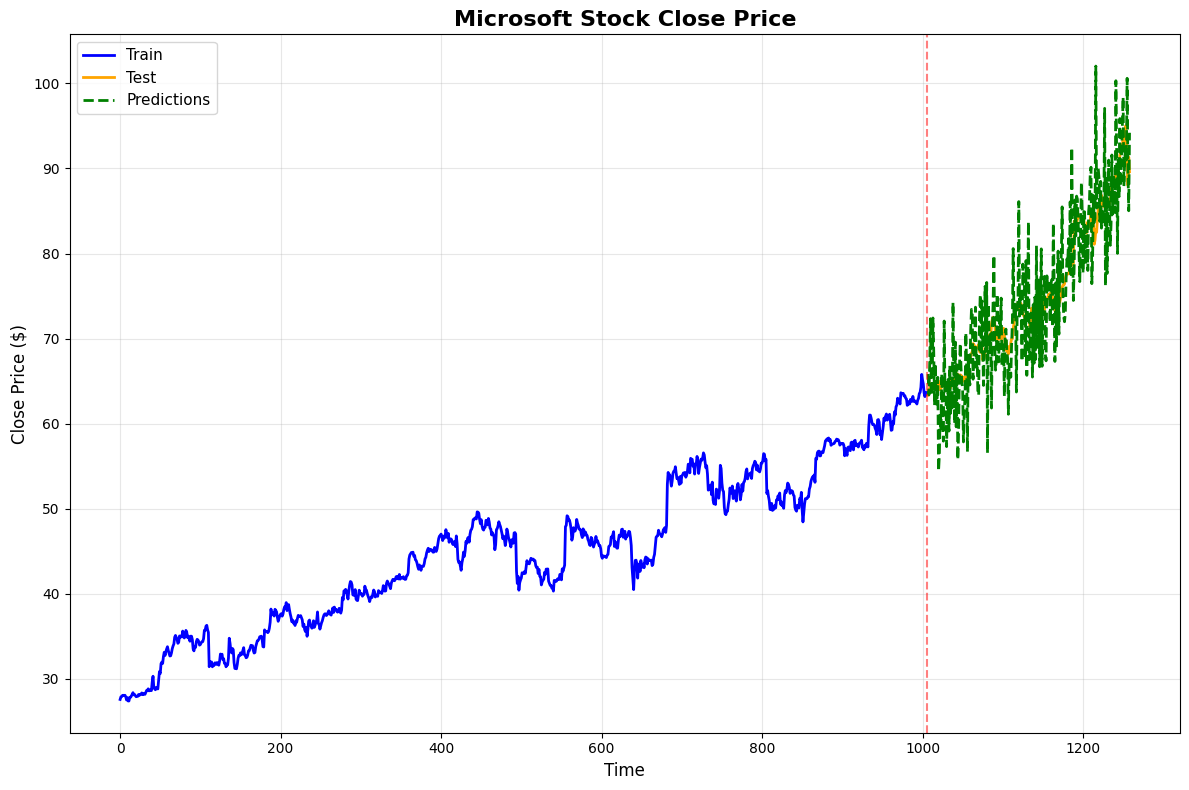

Training data size: 1007 points
Testing data size: 252 points
Prediction range: $54.41 - $102.04


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# Add any other imports you're using for your model (e.g., from sklearn.linear_model import LinearRegression)

# Assuming you have your data loaded (replace this with your actual data loading)
# microsoft = pd.read_csv('microsoft_stock.csv')

# Define the training split point (e.g., 80% for training)
training_size = int(len(microsoft) * 0.8)  # 80% training, 20% testing
# Or use a specific number: training_size = 800

# Split the data
train = microsoft.iloc[:training_size].copy()  # Training data
test = microsoft.iloc[training_size:].copy()   # Testing data

# ============================================
# YOUR MODEL TRAINING CODE HERE
# For demonstration, I'll create dummy predictions
# Replace this with your actual model and predictions
# ============================================

# Example: If you have a model
# model.fit(X_train, y_train)
# pred = model.predict(X_test)

# Creating dummy predictions for demonstration (replace with actual predictions)
np.random.seed(42)
last_train_value = train['close'].iloc[-1]
noise = np.random.normal(0, 5, len(test))
pred = test['close'].values + noise  # Dummy predictions

# ============================================
# Add predictions to test dataframe
test['Predictions'] = pred

# Plot the results
plt.figure(figsize=(12, 8))

# Plot training data
plt.plot(train.index, train['close'], c="blue", linewidth=2, label='Train')

# Plot actual test data
plt.plot(test.index, test['close'], c="orange", linewidth=2, label='Test')

# Plot predictions
plt.plot(test.index, test['Predictions'], c="green", linestyle='--', linewidth=2, label='Predictions')

# Customize the plot
plt.title('Microsoft Stock Close Price', fontsize=16, fontweight='bold')
plt.ylabel("Close Price ($)", fontsize=12)
plt.xlabel("Time", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Add vertical line to show train/test split
plt.axvline(x=train.index[-1], color='red', linestyle='--', alpha=0.5, label='Train/Test Split')

# Improve layout
plt.tight_layout()
plt.show()

# Optional: Print some statistics
print(f"Training data size: {len(train)} points")
print(f"Testing data size: {len(test)} points")
print(f"Prediction range: ${min(pred):.2f} - ${max(pred):.2f}")